# Mini Project 1 — Predicting Employee Attrition
### IBM HR Analytics Employee Attrition Dataset

**Goal:** Build a machine learning model that predicts whether an employee is likely to
leave the company (`Attrition`), based on HR data such as satisfaction, overtime, income,
job role, etc.

This notebook follows the 5 phases of the project:
1. Data Understanding (EDA)
2. Data Preprocessing
3. Model Building
4. Model Evaluation
5. Reporting (feature importance & insights)


## Phase 1: Data Understanding

First we load the libraries we need and the dataset, then look at its basic shape and structure.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make plots look clean and consistent
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

# Load the dataset
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")
print("Shape of the dataset (rows, columns):", df.shape)
df.head()


Shape of the dataset (rows, columns): (1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


**What we just did:** loaded the CSV into a pandas `DataFrame` — think of it like an
Excel sheet in Python. `df.shape` tells us how many employees (rows) and how many
attributes/columns we have.

In [2]:
# Column names and data types
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null   int64
 15

**Reading `df.info()`:** for each column it shows how many non-null (i.e. non-missing)
values there are, and the data type (`int64` = whole number, `object` = text/category).
If a column has fewer non-null values than the total row count, it has missing data.

In [3]:
# Check for missing values in every column
df.isnull().sum().sort_values(ascending=False)


Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

If every column shows `0`, this dataset has **no missing values** — that's common for
this particular Kaggle dataset, but it's always the first thing to check on any real
project.

In [4]:
# Statistical summary of numeric columns: mean, std, min, max, quartiles
df.describe()


,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


**Why this matters:** `describe()` helps us spot outliers or strange values quickly.
For example, if `Age` had a min of 5 or a max of 200, we'd know something's wrong.
It also shows us columns that never change (constant columns) — watch for columns where
min == max, e.g. `EmployeeCount`, `StandardHours`. Those carry no information for a model
and are candidates to drop later.

In [5]:
# Look for columns that are constant (same value in every row) - they add no predictive value
constant_cols = [c for c in df.columns if df[c].nunique() == 1]
print("Constant columns (no variation):", constant_cols)


Constant columns (no variation): ['EmployeeCount', 'Over18', 'StandardHours']


### Target variable: `Attrition`

This is what we're trying to predict: did the employee leave (`Yes`) or stay (`No`)?
Let's look at the class balance.

In [6]:
attrition_counts = df["Attrition"].value_counts()
attrition_pct = df["Attrition"].value_counts(normalize=True) * 100

print(attrition_counts)
print()
print(attrition_pct.round(2))


Attrition
No     1233
Yes     237
Name: count, dtype: int64

Attrition
No     83.88
Yes    16.12
Name: proportion, dtype: float64


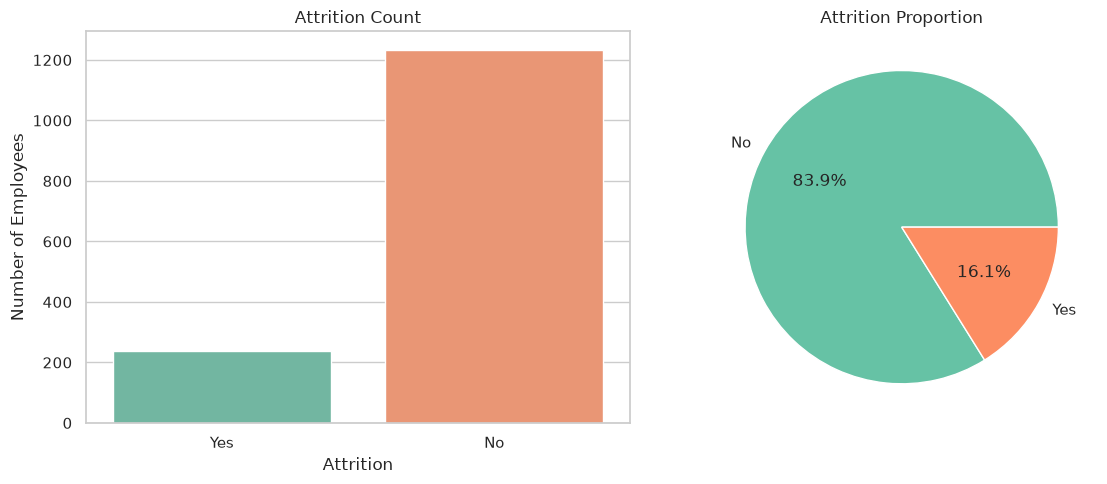

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(data=df, x="Attrition", hue="Attrition", palette="Set2", legend=False, ax=axes[0])
axes[0].set_title("Attrition Count")
axes[0].set_xlabel("Attrition")
axes[0].set_ylabel("Number of Employees")

axes[1].pie(attrition_counts, labels=attrition_counts.index, autopct="%1.1f%%",
            colors=sns.color_palette("Set2"))
axes[1].set_title("Attrition Proportion")

plt.tight_layout()
plt.savefig("attrition_distribution.png", dpi=120)
plt.show()


**This is the class imbalance the project brief warns about.** Roughly 84% of employees
stayed (`No`) and only ~16% left (`Yes`). If we trained a model without addressing this,
it could reach ~84% accuracy by *always* predicting "No" — technically "accurate" but
completely useless for identifying at-risk employees, which is the whole point of this
project. We'll fix this properly in Phase 2 (Data Preprocessing) using a technique called
**SMOTE**.

### Exploring relationships between features and Attrition

Let's visualize how a few HR-relevant features relate to attrition, to build intuition
before modeling.

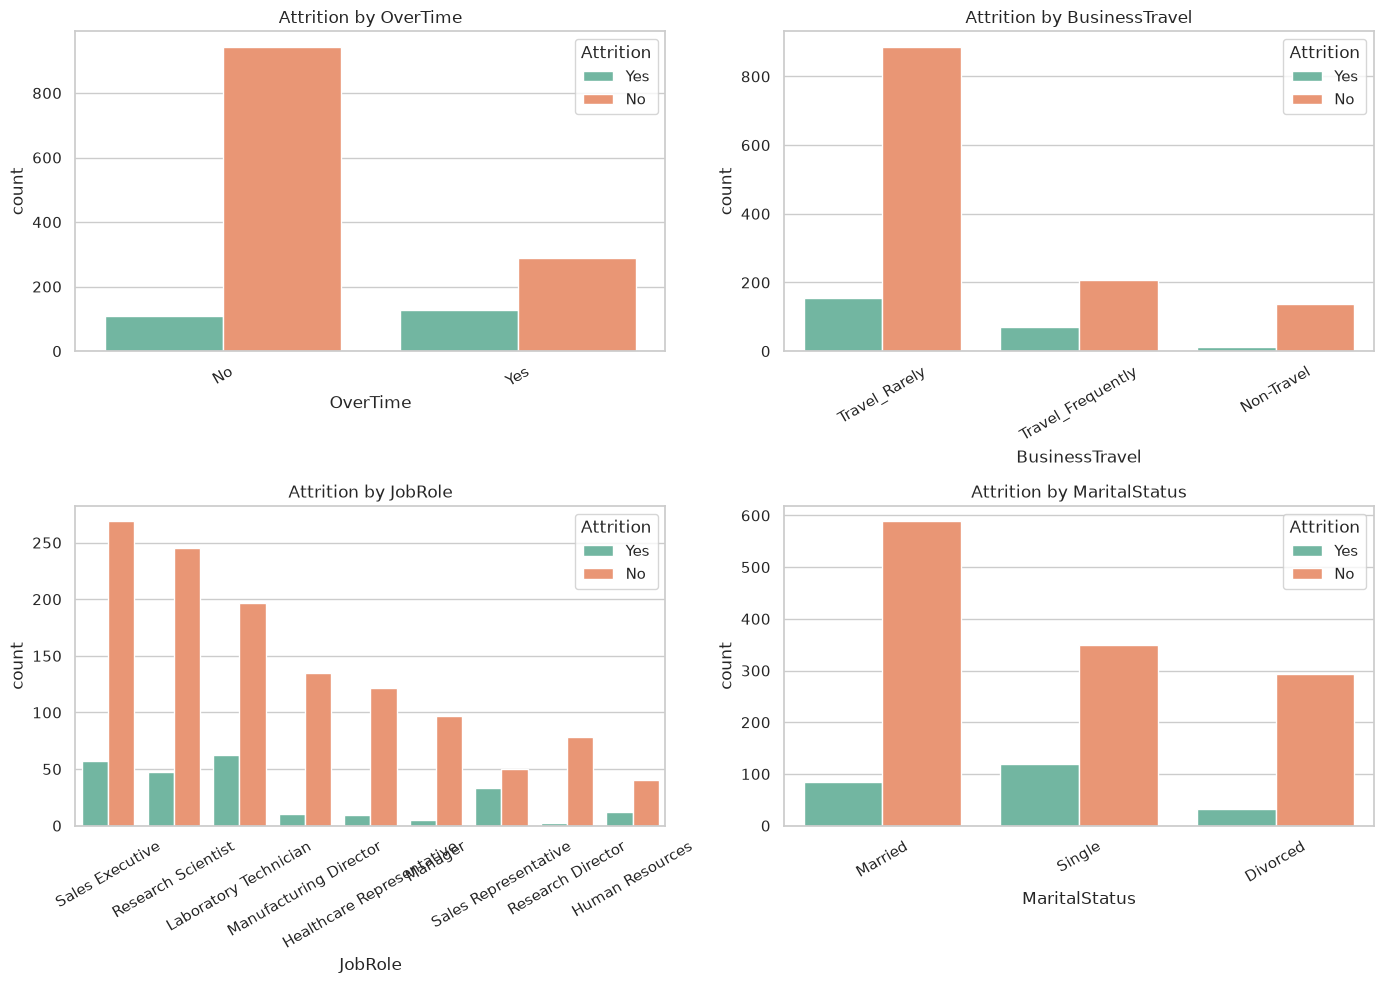

In [8]:
categorical_features = ["OverTime", "BusinessTravel", "JobRole", "MaritalStatus"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(categorical_features):
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, hue="Attrition", palette="Set2", ax=axes[i], order=order)
    axes[i].set_title(f"Attrition by {col}")
    axes[i].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig("attrition_by_categorical.png", dpi=120)
plt.show()


**What to look for:** if the orange/blue split looks very different across categories
of a feature (e.g. employees who work `OverTime` leaving far more often), that feature is
likely a strong predictor of attrition. Keep this in mind — we'll confirm it statistically
with feature importance in Phase 5.

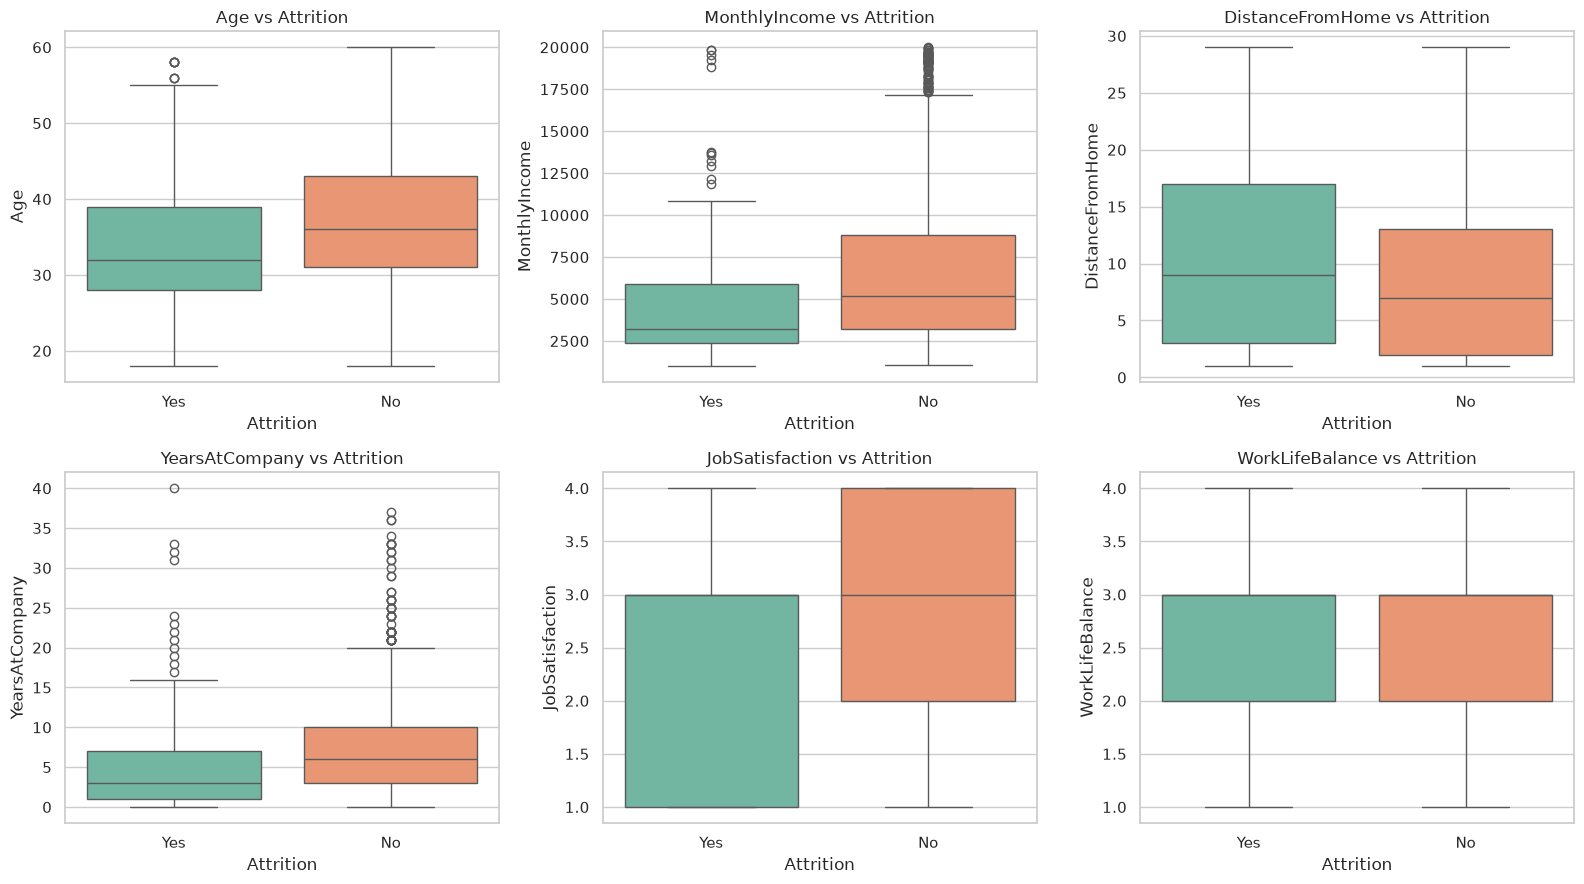

In [9]:
numeric_features = ["Age", "MonthlyIncome", "DistanceFromHome", "YearsAtCompany",
                     "JobSatisfaction", "WorkLifeBalance"]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(numeric_features):
    sns.boxplot(data=df, x="Attrition", y=col, hue="Attrition", palette="Set2",
                legend=False, ax=axes[i])
    axes[i].set_title(f"{col} vs Attrition")

plt.tight_layout()
plt.savefig("attrition_by_numeric.png", dpi=120)
plt.show()


**Reading a boxplot:** the box shows where the middle 50% of values fall, the line
inside is the median, and dots outside the whiskers are potential outliers. Comparing the
"Yes" box to the "No" box for each feature tells us whether that feature differs between
employees who leave and those who stay (e.g. do people who leave tend to be younger, or
earn less?).

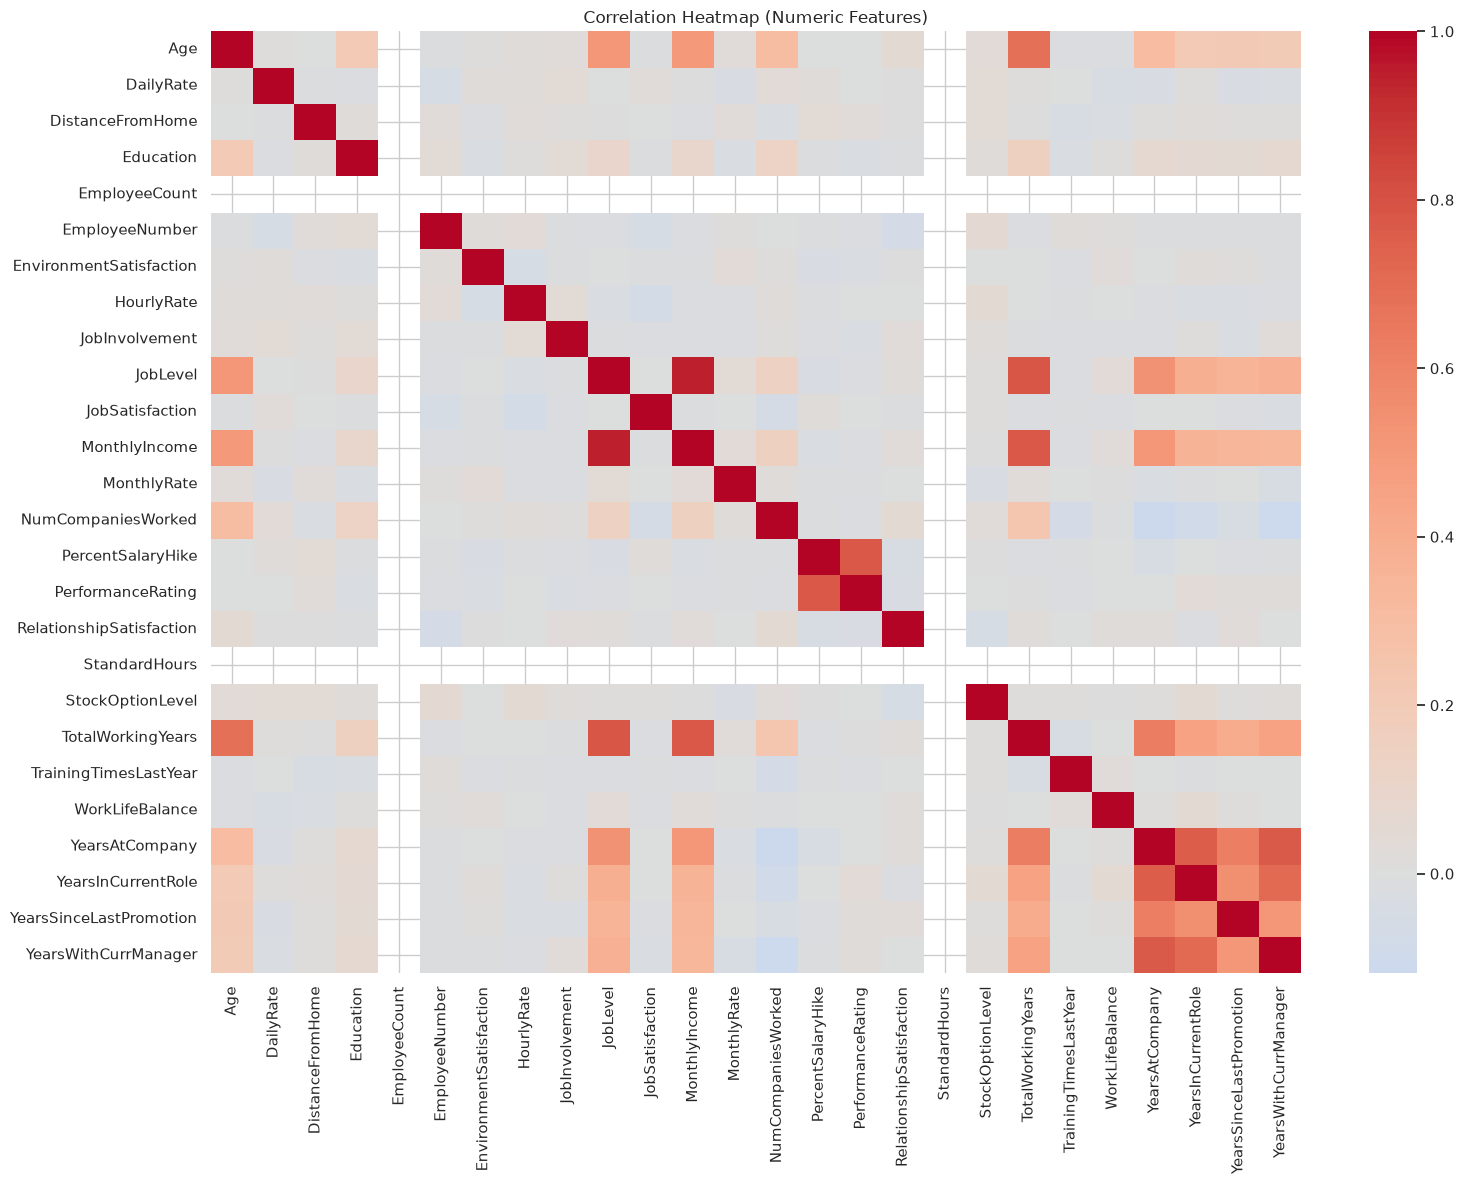

In [10]:
# Correlation heatmap for numeric features (helps spot multicollinearity later)
plt.figure(figsize=(16, 12))
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False)
plt.title("Correlation Heatmap (Numeric Features)")
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=120)
plt.show()


**Why check correlation:** highly correlated features (e.g. `JobLevel` and
`MonthlyIncome`) carry overlapping information. This isn't a problem for tree-based models,
but it can affect linear models like Logistic Regression. Good to know before we preprocess.

---
### Phase 1 Summary

- Dataset: 1470 employees, 35 columns, **no missing values**.
- A few columns are constant (`EmployeeCount`, `StandardHours`, possibly `Over18`) and
  will be dropped — they carry zero information.
- Target class `Attrition` is **imbalanced**: ~84% No vs ~16% Yes. We must handle this
  before modeling.
- Visual inspection suggests `OverTime`, `JobSatisfaction`, `WorkLifeBalance`, `MonthlyIncome`,
  and `Age` may be meaningfully related to attrition — we'll verify this formally later.

Next: **Phase 2 — Data Preprocessing.**
